# ML ZOOMCAMP CAPSTONE PROJECT


## 0 - Colab configuration & Data Donwload
* Open a new Google Colab, go to Runtime environment -> Change environment type -> T4 GPU, and follow these steps.
* Upload the kaggle.json file to the Colab files folder (folder icon on the left). Makes sure it is in yhe /content folder.

In [1]:
!pip install kaggle torch torchvision onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 83.7 MB/s eta 0:00:00


In [2]:
# Import libraries
import os
import zipfile

from pathlib import Path
import shutil
import random

from PIL import Image

import matplotlib.pyplot as plt

import matplotlib.image as mpimg
import seaborn as sns
import pandas as pd
import numpy as np

import hashlib

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from torchvision import models
import torch.nn as nn

import torch.optim as optim
from tqdm import tqdm

In [3]:
# --- SETTINGS ---
PROJECT_ROOT = Path("./")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw_temp"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

SEED = 42 # For reproducibility

In [4]:
os.environ['KAGGLE_CONFIG_DIR'] = '/content'
from kaggle.api.kaggle_api_extended import KaggleApi

In [5]:
"""
import os
import shutil

# The Kaggle API error message explicitly points to /root/.config/kaggle
kaggle_config_dir = os.path.join(os.path.expanduser('~'), '.config', 'kaggle')

if not os.path.exists(kaggle_config_dir):
    os.makedirs(kaggle_config_dir)

source_kaggle_json = '/content/kaggle.json'
dest_kaggle_json = os.path.join(kaggle_config_dir, 'kaggle.json')

if os.path.exists(source_kaggle_json) and not os.path.exists(dest_kaggle_json):
    shutil.move(source_kaggle_json, dest_kaggle_json)
    os.chmod(dest_kaggle_json, 0o600) # Set permissions
    print(f"Moved kaggle.json to {dest_kaggle_json} and set permissions.")
elif os.path.exists(dest_kaggle_json):
    print(f"kaggle.json already exists at {dest_kaggle_json}.")
else:
    print(f"kaggle.json not found at {source_kaggle_json}. Please ensure it's uploaded.")

# Ensure the KAGGLE_CONFIG_DIR is set correctly before importing KaggleApi
os.environ['KAGGLE_CONFIG_DIR'] = kaggle_config_dir
from kaggle.api.kaggle_api_extended import KaggleApi
"""

'\nimport os\nimport shutil\n\n# The Kaggle API error message explicitly points to /root/.config/kaggle\nkaggle_config_dir = os.path.join(os.path.expanduser(\'~\'), \'.config\', \'kaggle\')\n\nif not os.path.exists(kaggle_config_dir):\n    os.makedirs(kaggle_config_dir)\n\nsource_kaggle_json = \'/content/kaggle.json\'\ndest_kaggle_json = os.path.join(kaggle_config_dir, \'kaggle.json\')\n\nif os.path.exists(source_kaggle_json) and not os.path.exists(dest_kaggle_json):\n    shutil.move(source_kaggle_json, dest_kaggle_json)\n    os.chmod(dest_kaggle_json, 0o600) # Set permissions\n    print(f"Moved kaggle.json to {dest_kaggle_json} and set permissions.")\nelif os.path.exists(dest_kaggle_json):\n    print(f"kaggle.json already exists at {dest_kaggle_json}.")\nelse:\n    print(f"kaggle.json not found at {source_kaggle_json}. Please ensure it\'s uploaded.")\n\n# Ensure the KAGGLE_CONFIG_DIR is set correctly before importing KaggleApi\nos.environ[\'KAGGLE_CONFIG_DIR\'] = kaggle_config_dir\nfr

In [6]:
def download_dataset():
    if RAW_DATA_DIR.exists():
        print("The temporary download folder already exists. Skipping download..")
        return

    print("Downloading dataset from Kaggle...")
    api = KaggleApi()
    api.authenticate()

    api.dataset_download_files("anujms/car-damage-detection", path=RAW_DATA_DIR, unzip=True)

    for zip_file in RAW_DATA_DIR.glob("*.zip"):
        zip_file.unlink()

    print(f"Download completed in: {RAW_DATA_DIR}")

download_dataset()

Dataset URL: https://www.kaggle.com/datasets/anujms/car-damage-detection
Download completed in: data/raw_temp


## 1 - Data Preparation
* Cleaning corrupted images.
* Cleaning dupplicates.
* Splitting data.

In [7]:
def clean_images(folder_path):
    print(f"\n Starting cleaning in: {folder_path}")
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    deleted_count = 0
    checked_count = 0

    for filepath in folder_path.rglob("*"):
        if filepath.is_file() and filepath.suffix.lower() in valid_exts:
            checked_count += 1
            try:
                with Image.open(filepath) as img:
                    img.verify()
            except (IOError, SyntaxError, Image.DecompressionBombError) as e:
                print(f"Corrupted image removed: {filepath.name}")
                filepath.unlink() # Borrar archivo
                deleted_count += 1

    print(f"Cleaning finished. Checked: {checked_count}. Deleted: {deleted_count}.")

clean_images(RAW_DATA_DIR)


 Starting cleaning in: data/raw_temp
Cleaning finished. Checked: 2300. Deleted: 0.


In [8]:
def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for filepath in folder_path.rglob("*"):
        if filepath.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            with open(filepath, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in hashes:
                duplicates.append((filepath, hashes[file_hash]))
            else:
                hashes[file_hash] = filepath

    return duplicates

dupes = find_duplicates(RAW_DATA_DIR)

print(f"{len(dupes)} exact duplicate images were found.")
if len(dupes) > 0:
    print("Example:", dupes[0])

13 exact duplicate images were found.
Example: (PosixPath('data/raw_temp/data1a/training/00-damage/0355.JPEG'), PosixPath('data/raw_temp/data1a/training/00-damage/0043.JPEG'))


In [9]:
# Delete duplicates
for dup in dupes:
    os.remove(dup[0])

### 1.1 - Split Dataset

In [10]:
def create_splits():
    random.seed(SEED)

    if PROCESSED_DATA_DIR.exists():
        shutil.rmtree(PROCESSED_DATA_DIR)

    splits = ['train', 'val', 'test']
    labels = ['damage', 'whole']

    for split in splits:
        for label in labels:
            (PROCESSED_DATA_DIR / split / label).mkdir(parents=True, exist_ok=True)

    def get_files_by_label(keyword):
        files = []
        for filepath in RAW_DATA_DIR.rglob("*"):
            if filepath.is_file() and filepath.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
                if keyword in filepath.parent.name.lower():
                    files.append(filepath)
        return files

    for label in labels:
        all_files = get_files_by_label(label)

        random.shuffle(all_files)

        total = len(all_files)
        if total == 0:
            print(f"Warning: No images found for the tag '{label}'")
            continue

        train_end = int(total * TRAIN_RATIO)
        val_end = train_end + int(total * VAL_RATIO)

        split_files = {
            'train': all_files[:train_end],
            'val':   all_files[train_end:val_end],
            'test':  all_files[val_end:]
        }

        print(f"Processing class '{label}': Total {total}")
        print(f"   ↳ Train: {len(split_files['train'])} | Val: {len(split_files['val'])} | Test: {len(split_files['test'])}")

        for split, files in split_files.items():
            for f in files:
                shutil.copy2(f, PROCESSED_DATA_DIR / split / label / f.name)

    print(f"\n Dataset successfully prepared in: {PROCESSED_DATA_DIR}")

create_splits()

Processing class 'damage': Total 1138
   ↳ Train: 682 | Val: 227 | Test: 229
Processing class 'whole': Total 1149
   ↳ Train: 689 | Val: 229 | Test: 231

 Dataset successfully prepared in: data/processed


In [11]:
for split in ['train', 'val', 'test']:
    for label in ['damage', 'whole']:
        path = PROCESSED_DATA_DIR / split / label
        count = len(list(path.glob('*')))
        print(f"{split}/{label}: {count} imágenes")

train/damage: 613 imágenes
train/whole: 615 imágenes
val/damage: 220 imágenes
val/whole: 219 imágenes
test/damage: 220 imágenes
test/whole: 223 imágenes


## 2 - Prepare the "Dataloaders" (PyTorch)
To transform the images so that the network understands them (Tensors, Normalisation).

In [12]:
BATCH_SIZE = 32
IMG_SIZE = 224  # Standard size for MobileNet/ResNet

# Transformations (Augmentation for Train, Normalisation for Val and test)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),  # Mirror
        transforms.RandomRotation(10),      # Rotate slightly
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'eval': transforms.Compose([ # Same one for Val and Test.
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [13]:
train_ds = datasets.ImageFolder("data/processed/train", transform=data_transforms['train'])
val_ds = datasets.ImageFolder("data/processed/val", transform=data_transforms['eval'])
test_ds = datasets.ImageFolder("data/processed/test", transform=data_transforms['eval'])

In [14]:
dataloaders = {
    'train': DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
    'val': DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False),
    'test': DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
}

In [15]:
dataloaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x795c61daee10>,
 'val': <torch.utils.data.dataloader.DataLoader at 0x795d598460f0>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x795c61e7e840>}

In [16]:
print(f"Data loaded:")
print(f"Train: {len(train_ds)} images")
print(f"Val:   {len(val_ds)} images")
print(f"Test:  {len(test_ds)} images")
class_names = train_ds.classes
print(f"Classes detected: {class_names}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Data loaded:
Train: 1228 images
Val:   439 images
Test:  443 images
Classes detected: ['damage', 'whole']
Using device: cuda


## 3 - Train a base model
In this phase, I will do basic training without tuning, to have a base model.

### 3.1 - Define the Model (Transfer Learning)
We will use MobileNetV3 Small. It is fast and ideal for web applications.

In [17]:
# Download pre-trained model
model = models.mobilenet_v3_small(weights='DEFAULT')

# Freeze base weights (so as not to break what you already know)
for param in model.parameters():
    param.requires_grad = False

# 3. Change the last layer (Classifier)
# The original layer has 1,000 outputs (ImageNet), we want 2 (Damage vs Whole).
num_ftrs = model.classifier[3].in_features
model.classifier[3] = nn.Linear(num_ftrs, 2)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 44.5MB/s]


### 3.2 - Training

In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

def train_model(model, epochs=5):
    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return model

# Training
epochs = 10

trained_model = train_model(model, epochs=epochs)

Epoch 1/10
----------


100%|██████████| 39/39 [00:09<00:00,  4.24it/s]


train Loss: 0.4698 Acc: 0.7834


100%|██████████| 14/14 [00:03<00:00,  4.51it/s]


val Loss: 0.9914 Acc: 0.5626
Epoch 2/10
----------


...

val Loss: 0.3071 Acc: 0.8679
Epoch 10/10
----------


100%|██████████| 39/39 [00:06<00:00,  6.28it/s]


train Loss: 0.2230 Acc: 0.9145


100%|██████████| 14/14 [00:02<00:00,  6.17it/s]

val Loss: 0.3127 Acc: 0.8656


### 3.3 - Evaluate the Test Set

In [19]:
def evaluate_test(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f'Final Accuracy in Test Set: {acc:.2f}%')

evaluate_test(trained_model, dataloaders['test'])

Final Accuracy in Test Set: 88.04%


### 3.4 - Export to ONNX
Once the model have decent accuracy (>85%), export it to take it to Docker.

In [20]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 12.1 MB/s eta 0:00:00


In [21]:
trained_model.eval()

dummy_input = torch.randn(1, 3, 224, 224).to(device)

onnx_path = "car_damage.onnx"
torch.onnx.export(
    trained_model,
    dummy_input,
    onnx_path,
    verbose=False,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print(f"Model saved as {onnx_path}. Download it!")

/tmp/ipython-input-1881070964.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


Applied 69 of general pattern rewrite rules.
Model saved as car_damage.onnx. Download it!


## 4 - Tunning the model
Now I am going to create a structure to be able to tune the model:

* Defines a Flexible Model Class (that accepts the two tuning variables,  internal size and dropout as arguments).
* Has a Training Function that returns the history (for graphing purposes).
* Runs Experiment Loops comparing parameters.

### 4.1 - Definition of the Flexible Model (Custom Class)
I will use a modern and flexible model, adapting the "head" (the last layers) to include the parameters we want to fine-tune (size_inner, dropout).

In [22]:
import torch
import torch.nn as nn
from torchvision import models

class CarDamageModel(nn.Module):
    def __init__(self, size_inner=100, droprate=0.2, num_classes=2):
        super(CarDamageModel, self).__init__()

        # Load MobileNetV3 Small
        self.backbone = models.mobilenet_v3_small(weights='DEFAULT')

        for param in self.backbone.parameters():
            param.requires_grad = False

        input_features = 576

        self.classifier = nn.Sequential(
            nn.Linear(input_features, size_inner),
            nn.ReLU(),
            nn.Dropout(droprate),
            nn.Linear(size_inner, num_classes)
        )

        self.backbone.classifier = self.classifier

    def forward(self, x):
        return self.backbone(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model defined. Using device: {device}")

Model defined. Using device: cuda


### 4.2 - Training Engine
This function trains, validates, saves the best model, and returns the history for graphing.

In [23]:
import copy
import torch.optim as optim

def train_and_evaluate(model, learning_rate, num_epochs, train_loader, val_loader):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.backbone.classifier.parameters(), lr=learning_rate)

    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    # History for graphs
    history = {
        'train_acc': [], 'val_acc': []
    }

    print(f"* Starting training: LR={learning_rate} | Epochs={num_epochs}")

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_corrects = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_train += labels.size(0)

        epoch_train_acc = running_corrects.double() / total_train
        history['train_acc'].append(epoch_train_acc.item())

        # Validation
        model.eval()
        val_corrects = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)
                total_val += labels.size(0)

        epoch_val_acc = val_corrects.double() / total_val
        history['val_acc'].append(epoch_val_acc.item())

        # Storing best model
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(f"   Ep {epoch+1}/{num_epochs}: Train Acc: {epoch_train_acc:.3f} | Val Acc: {epoch_val_acc:.3f}")

    print(f"* Best Val Acc achieved: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history, best_acc

### 4.3 - Experiment A: Finding the best learning rate
We will test three different values and plot which one converges best.

* Starting training: LR=0.001 | Epochs=10
   Ep 5/10: Train Acc: 0.871 | Val Acc: 0.815
   Ep 10/10: Train Acc: 0.902 | Val Acc: 0.886
* Best Val Acc achieved: 0.8861
* Starting training: LR=0.01 | Epochs=10
   Ep 5/10: Train Acc: 0.843 | Val Acc: 0.756
   Ep 10/10: Train Acc: 0.863 | Val Acc: 0.900
* Best Val Acc achieved: 0.9089
* Starting training: LR=0.1 | Epochs=10
   Ep 5/10: Train Acc: 0.800 | Val Acc: 0.863
   Ep 10/10: Train Acc: 0.785 | Val Acc: 0.884
* Best Val Acc achieved: 0.8929


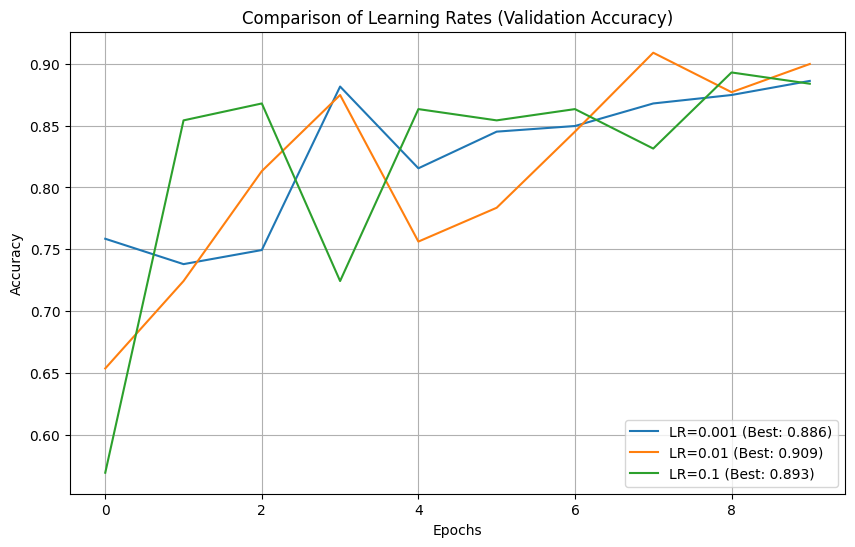

In [26]:
import matplotlib.pyplot as plt

EPOCHS = 10
SIZE_INNER = 100
DROPOUT = 0.2

learning_rates = [0.001, 0.01, 0.1]
results_lr = {}

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    model = CarDamageModel(size_inner=SIZE_INNER, droprate=DROPOUT).to(device)

    best_model, history, best_acc = train_and_evaluate(
        model, lr, EPOCHS, dataloaders['train'], dataloaders['val']
    )

    results_lr[lr] = {'history': history, 'best_acc': best_acc}

    plt.plot(history['val_acc'], label=f'LR={lr} (Best: {best_acc:.3f})')

plt.title('Comparison of Learning Rates (Validation Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

We can see that the best LR is 0.01.

### 4.4 - Experiment B: Adjusting size_inner and dropout
Now we set the best LR from the previous step (0.001) and test architectures.


* Testing configuration: Small_HighDrop -> Inner: 64, Drop: 0.5
* Starting training: LR=0.01 | Epochs=15
   Ep 5/15: Train Acc: 0.839 | Val Acc: 0.836
   Ep 10/15: Train Acc: 0.849 | Val Acc: 0.841
   Ep 15/15: Train Acc: 0.846 | Val Acc: 0.854
* Best Val Acc achieved: 0.8838

* Testing configuration: Big_LowDrop -> Inner: 256, Drop: 0.2
* Starting training: LR=0.01 | Epochs=15
   Ep 5/15: Train Acc: 0.867 | Val Acc: 0.847
   Ep 10/15: Train Acc: 0.888 | Val Acc: 0.861
   Ep 15/15: Train Acc: 0.891 | Val Acc: 0.820
* Best Val Acc achieved: 0.8975

* Testing configuration: Balanced -> Inner: 128, Drop: 0.3
* Starting training: LR=0.01 | Epochs=15
   Ep 5/15: Train Acc: 0.849 | Val Acc: 0.831
   Ep 10/15: Train Acc: 0.882 | Val Acc: 0.843
   Ep 15/15: Train Acc: 0.878 | Val Acc: 0.802
* Best Val Acc achieved: 0.8952

* -> OVERALL WINNER: Big_LowDrop con Acc: 0.8975


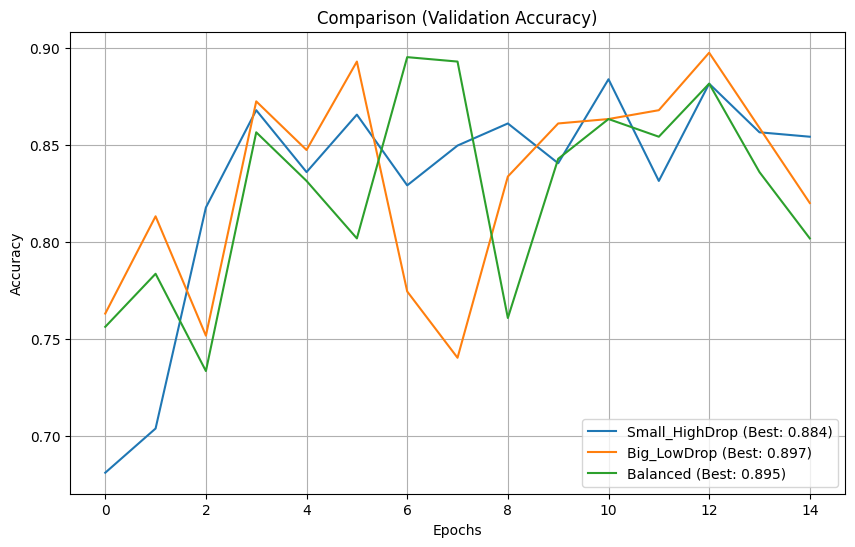

In [27]:
# Best LR from previous cell
BEST_LR = 0.01
EPOCHS = 15

configs = {
    'Small_HighDrop': {'inner': 64,  'drop': 0.5},
    'Big_LowDrop':    {'inner': 256, 'drop': 0.2},
    'Balanced':       {'inner': 128, 'drop': 0.3}
}

best_overall_model = None
best_overall_acc = 0.0
best_config_name = ""

plt.figure(figsize=(10, 6))

for name, cfg in configs.items():
    print(f"\n* Testing configuration: {name} -> Inner: {cfg['inner']}, Drop: {cfg['drop']}")

    model = CarDamageModel(size_inner=cfg['inner'], droprate=cfg['drop']).to(device)

    trained_model, history, acc = train_and_evaluate(
        model, BEST_LR, EPOCHS, dataloaders['train'], dataloaders['val']
    )

    plt.plot(history['val_acc'], label=f'{name} (Best: {acc:.3f})')

    # Guardar el ganador absoluto
    if acc > best_overall_acc:
        best_overall_acc = acc
        best_overall_model = trained_model
        best_config_name = name

print(f"\n* -> OVERALL WINNER: {best_config_name} con Acc: {best_overall_acc:.4f}")

plt.title('Comparison (Validation Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### 4.5 - Final Evaluation and Export
Once we have the best_overall_model (the winner of all experiments), we test it against the Test Set (which it has never seen before) and export it.

In [28]:
# Final assessment in Test Set
def evaluate_test_set(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

test_acc = evaluate_test_set(best_overall_model, dataloaders['test'])
print(f"-> Final Accuracy in Test Set: {test_acc:.2%}")



-> Final Accuracy in Test Set: 90.97%


As we can see, we achieved an improvement of almost 3.5% in the test compared to a model without tuning.

In [29]:
# Export to ONNX
dummy_input = torch.randn(1, 3, 224, 224).to(device)
onnx_path = "best_car_damage_model.onnx"

torch.onnx.export(
    best_overall_model,
    dummy_input,
    onnx_path,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print(f"Template saved as {onnx_path}")

/tmp/ipython-input-769700210.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `CarDamageModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CarDamageModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 69 of general pattern rewrite rules.
Template saved as best_car_damage_model.onnx
